# 📊 Model Evaluation - UAV Waterfowl Detection

Comprehensive evaluation of the trained model including:
- Test set metrics
- Error analysis (TP, FP, FN)
- Visualization of detections
- Performance interpretation

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.append('../')

from models.evaluate import WaterfowlEvaluator
from data import config

print("✓ Setup complete!")

✓ Setup complete!


## 📥 Load Trained Model

**Important:** Update the model path to your trained model!

In [2]:
# find the latest model automatically
model_files = list(config.WEIGHTS_PATH.glob("waterfowl_*_best.pt"))
if model_files:
    MODEL_PATH = sorted(model_files)[-1]  # Get most recent
    print(f"Found model: {MODEL_PATH.name}")
else:
    print("⚠️ No trained model found! Please train a model first.")

# Initialize evaluator
evaluator = WaterfowlEvaluator(str(MODEL_PATH))

Found model: waterfowl_yolov8n_20251105_121108_best.pt

Loading model: /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/notebooks/../outputs/weights/waterfowl_yolov8n_20251105_121108_best.pt
✓ Model loaded successfully


## 🧪 Run Test Set Evaluation

In [3]:
results = evaluator.evaluate_on_test_set()


EVALUATING ON TEST SET
Ultralytics 8.3.221 🚀 Python-3.12.2 torch-2.7.0+cu126 CUDA:0 (Quadro M600M, 1993MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3573.4±776.0 MB/s, size: 555.0 KB)
val: Scanning /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/processed_data/yolo_format/labels/test.cache... 83 images, 29 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 101.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.2s0.8ss
                   all         83       1411      0.932      0.778      0.864      0.518
Speed: 4.7ms preprocess, 35.5ms inference, 0.0ms loss, 2.9ms postprocess per image
Saving /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/outputs/results/waterfowl_yolov8n_20251105_121108_best_eval/test_results/predictions.json...
Results saved to /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/outputs/result

## 🔍 Error Analysis

In [4]:
analysis = evaluator.analyze_predictions()


ANALYZING PREDICTIONS

Processing 83 test images...


Analyzing: 100%|██████████| 83/83 [00:03<00:00, 21.14it/s]


✓ Analysis complete!
  True Positives: 1172
  False Positives: 82
  False Negatives: 239


## 🎨 Visualize Examples

In [5]:
evaluator.visualize_examples(analysis, num_examples=3)


CREATING VISUALIZATIONS

Generating True Positive examples...
  ✓ Saved: /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/notebooks/../outputs/visualizations/waterfowl_yolov8n_20251105_121108_best_eval/true_positives.png
Generating False Positive examples...
  ✓ Saved: /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/notebooks/../outputs/visualizations/waterfowl_yolov8n_20251105_121108_best_eval/false_positives.png
Generating False Negative examples...
  ✓ Saved: /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/notebooks/../outputs/visualizations/waterfowl_yolov8n_20251105_121108_best_eval/false_negatives.png
✓ Visualizations saved!


### View True Positives (Correct Detections)

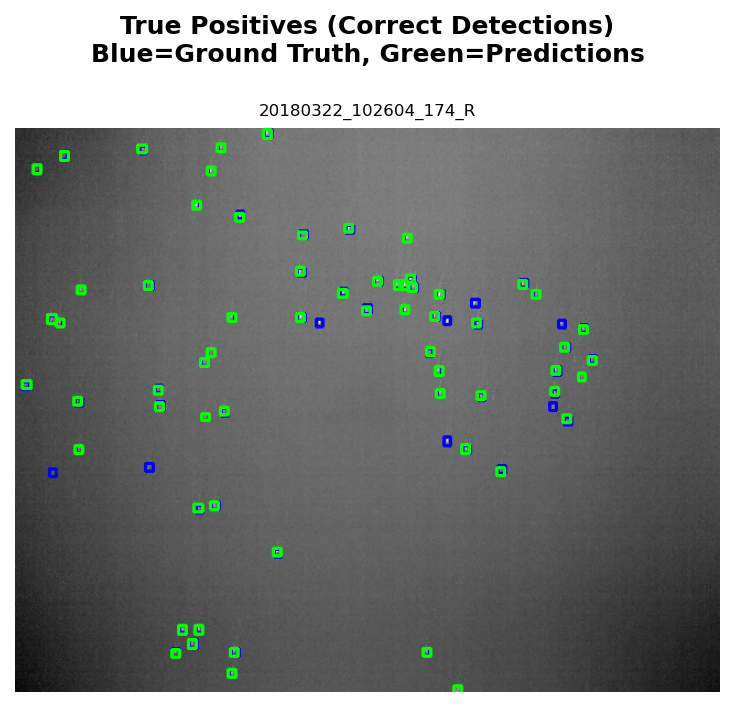

In [6]:
tp_viz = evaluator.viz_dir / "true_positives.png"
if tp_viz.exists():
    display(Image(filename=str(tp_viz), width=1200))

### View False Positives (Incorrect Detections)

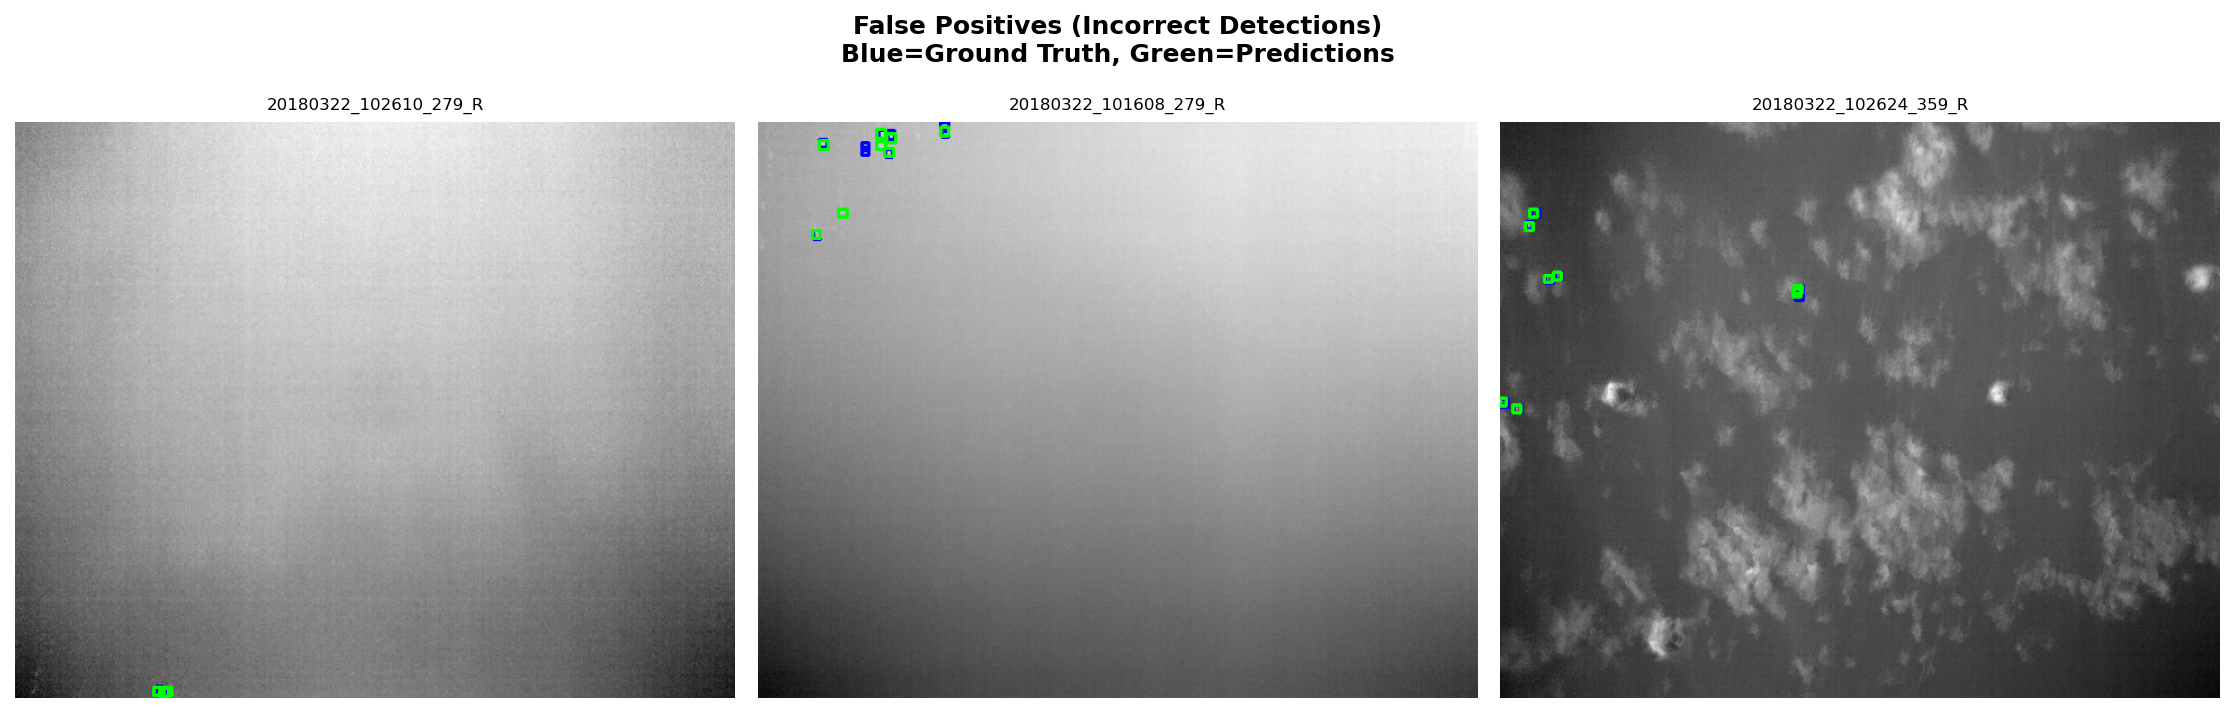

In [7]:
fp_viz = evaluator.viz_dir / "false_positives.png"
if fp_viz.exists():
    display(Image(filename=str(fp_viz), width=1200))

### View False Negatives (Missed Detections)

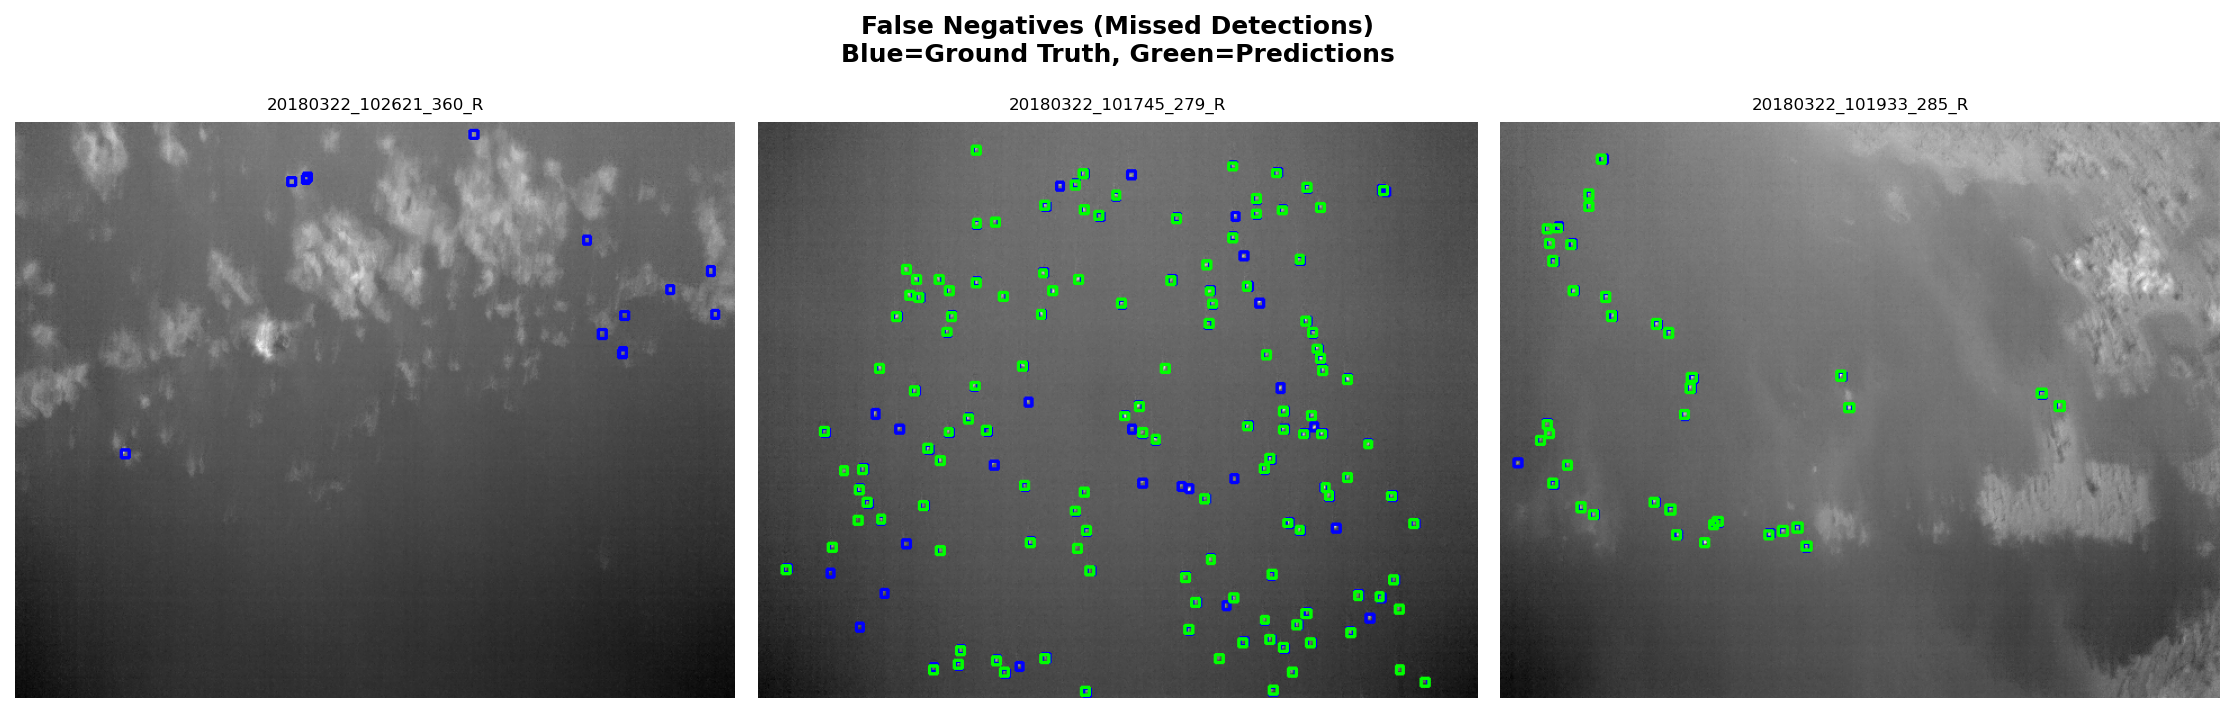

In [8]:
fn_viz = evaluator.viz_dir / "false_negatives.png"
if fn_viz.exists():
    display(Image(filename=str(fn_viz), width=1200))

## 📝 Generate Summary Report

In [9]:
evaluator.create_summary_report(analysis)


GENERATING SUMMARY REPORT
✓ Report saved to: /home/mehran/thws/Computer Vision/Portfolio 1/CV_1/notebooks/../outputs/results/waterfowl_yolov8n_20251105_121108_best_eval/evaluation_report.txt

WATERFOWL DETECTION - EVALUATION REPORT

Model: waterfowl_yolov8n_20251105_121108_best.pt
Test set: 83 images

--------------------------------------------------------------------------------
METRICS
--------------------------------------------------------------------------------
  precision      : 0.9321
  recall         : 0.7782
  mAP50          : 0.8644
  mAP50-95       : 0.5178
  f1             : 0.8482

--------------------------------------------------------------------------------
ERROR ANALYSIS
--------------------------------------------------------------------------------
  True Positives:  1172
  False Positives: 82
  False Negatives: 239
  Total GT boxes:  1411
  Total Pred boxes: 1254

  Precision (TP/TP+FP): 0.9346
  Recall (TP/TP+FN):    0.8306
  F1 Score:             0.8795

INTER